# Task 1 : Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Task 2 : Uploading data

In [2]:
df = pd.read_csv('modified_placement_data.csv')

# Task 3 : Understanding Data

In [3]:
df

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No
...,...,...,...
95,"4,3",200.0,No
96,"4,4",42.0,No
97,"6,7",182.0,Yes
98,"6,3",103.0,Yes


In [4]:
df.head()

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


In [5]:
df.tail()

,cgpa,iq,placement
95,"4,3",200.0,No
96,"4,4",42.0,No
97,"6,7",182.0,Yes
98,"6,3",103.0,Yes
99,"6,2",113.0,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [7]:
df.describe()

,iq
count,100.000000
mean,123.580000
std,39.944198
min,37.000000
25%,101.500000
50%,127.500000
75%,149.000000
max,233.000000


In [8]:
df.isnull().sum()

cgpa         5
iq           0
placement    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

# Task 4 : Data Cleaning

In [10]:
df['cgpa'] = df['cgpa'].str.split(',').str.join('.').astype('float')

In [11]:
df = df[~df['cgpa'].isnull()]

# Task 5 : Data Visualization

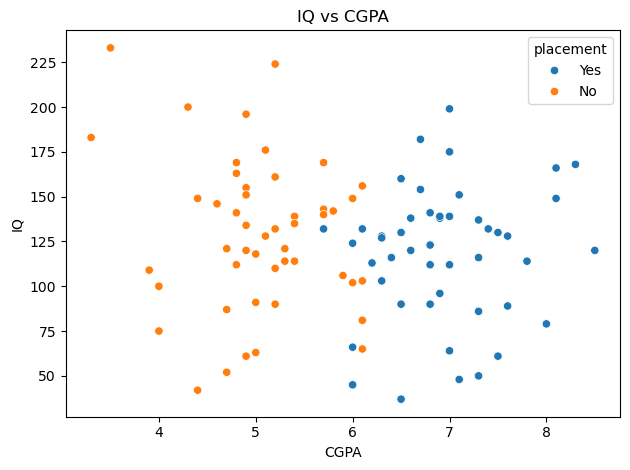

In [12]:
sns.scatterplot(data = df, x = 'cgpa', y = 'iq', hue = 'placement')
plt.title('IQ vs CGPA')
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.tight_layout()
plt.show()

# Task 6 : ML model Training

In [13]:
X = df.iloc[:, 0:2]
Y = df.iloc[:, -1]

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1)

In [15]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.fit_transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train, Y_train)

LogisticRegression()

In [17]:
y_predict = clf.predict(X_test)

In [18]:
y_predict

array(['No', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes'],
      dtype=object)

# Task 7 : Model accuracy check

In [19]:
from sklearn.metrics import accuracy_score

accuracy_score(Y_test, y_predict)

0.9